# 03 — Churn EDA: Feature Dağılımları ve Sınıf Dengesi

Bu notebook, `churn/feature_engineering.py`'deki gerçek feature mühendisliği
fonksiyonlarını kullanarak (production kod ile aynı fonksiyonlar — kopya SQL
yok) churn etiketinin sınıf dengesini ve RFM/davranışsal feature'ların churn
olan/olmayan müşteriler arasında nasıl ayrıştığını inceler.

İlgili model kartı: `model_cards/churn.md`


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))  # /app'i sys.path'e ekle (app paketi için)

%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime, timedelta, timezone

from app.churn.feature_engineering import FEATURE_COLUMNS, build_customer_features, label_churn
from app.churn.train import LABEL_HORIZON_DAYS, SNAPSHOT_LAG_DAYS
from app.common.database import SessionLocal

db = SessionLocal()
snapshot_date = datetime.now(timezone.utc) - timedelta(days=SNAPSHOT_LAG_DAYS)
features_df = build_customer_features(db, snapshot_date)
labels_df = label_churn(db, snapshot_date, LABEL_HORIZON_DAYS)
df = features_df.merge(labels_df, on="customer_id", how="inner")
db.close()

print(f"Örneklem: {len(df)} müşteri, snapshot={snapshot_date.date()}")
df.head()


Örneklem: 269 müşteri, snapshot=2026-03-28


,customer_id,recency_days,frequency,avg_order_value,monetary_total,trend_ratio,category_diversity,anomaly_ratio,tenure_days,churn
0,027a207d-91c6-47ed-a627-2ec48e25de65,2.0,70,5636.119714,394528.38,5.619624,5,0.0,548.0,0
1,02ba54f0-5f3c-454b-9351-a31623936efb,3.0,69,3046.891594,210235.52,0.431675,5,0.0,496.0,0
2,03b0ae0b-e374-4eab-ba5a-125976e8588b,52.0,41,4009.127561,164374.23,0.010320,5,0.0,545.0,0
3,03b4ebd7-6eb5-4bde-9a11-16fafbe02fe9,36.0,29,2916.545862,84579.83,0.778968,5,0.0,577.0,1
4,05026bdf-89f9-4f1d-9c7f-91a27b8ecfdc,21.0,58,2712.902241,157348.33,1.060996,5,0.0,547.0,0


## 1. Sınıf dengesi

churn
0    210
1     59
Name: count, dtype: int64
Churn oranı: %21.9


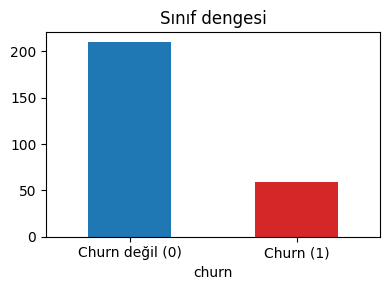

In [2]:
churn_counts = df["churn"].value_counts().sort_index()
print(churn_counts)
print(f"Churn oranı: %{100 * df['churn'].mean():.1f}")

fig, ax = plt.subplots(figsize=(4, 3))
churn_counts.plot(kind="bar", ax=ax, color=["tab:blue", "tab:red"])
ax.set_xticklabels(["Churn değil (0)", "Churn (1)"], rotation=0)
ax.set_title("Sınıf dengesi")
plt.tight_layout()
plt.savefig("03_class_balance.png", dpi=80)
plt.show()


## 2. Feature dağılımları — churn olan vs olmayan

Her feature için churn=0 ve churn=1 gruplarının dağılımları karşılaştırılır.
Belirgin bir ayrışma (örn. `recency_days`'in churn=1'de sistematik olarak daha
yüksek olması), o feature'ın modele gerçek bir sinyal taşıdığının görsel kanıtıdır.

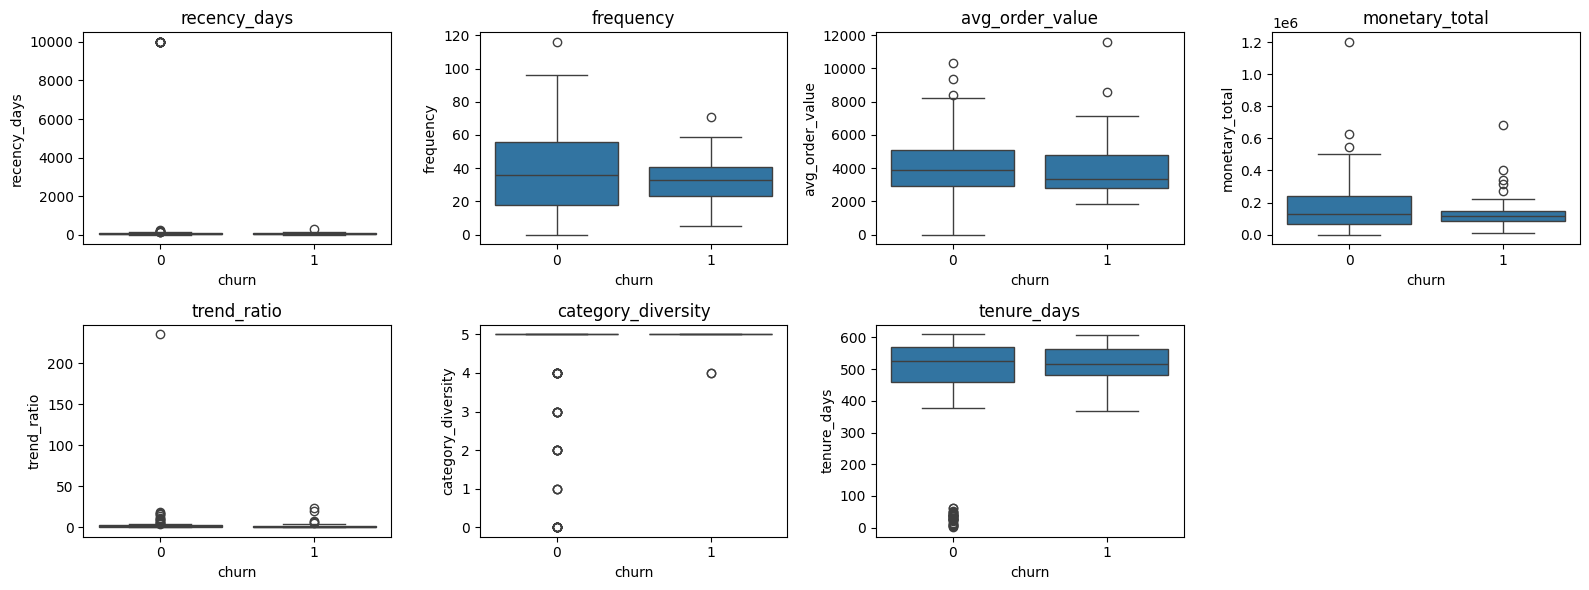

In [3]:
numeric_features = [c for c in FEATURE_COLUMNS if df[c].nunique() > 2]
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, numeric_features):
    sns.boxplot(data=df, x="churn", y=col, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(numeric_features):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig("03_feature_distributions.png", dpi=80)
plt.show()


## 3. Feature — churn ortalama karşılaştırma tablosu

In [4]:
summary = df.groupby("churn")[FEATURE_COLUMNS].mean().T
summary.columns = ["churn=0 ortalama", "churn=1 ortalama"]
summary["fark"] = summary["churn=1 ortalama"] - summary["churn=0 ortalama"]
summary.sort_values("fark", key=abs, ascending=False)


,churn=0 ortalama,churn=1 ortalama,fark
monetary_total,164111.463095,136571.161356,-27540.301739
recency_days,603.457143,60.864407,-542.592736
avg_order_value,3955.499007,4038.311844,82.812837
tenure_days,455.428571,515.627119,60.198547
frequency,37.833333,33.000000,-4.833333
trend_ratio,2.980199,1.687403,-1.292796
category_diversity,4.466667,4.966102,0.499435
anomaly_ratio,0.000000,0.000000,0.000000


## Sonuç

- Churn oranı, `model_cards/churn.md`'de raporlanan CV örnekleminin churn oranıyla
  tutarlı olmalı (aynı snapshot/horizon mantığı kullanılıyor).
- `recency_days` ve `trend_ratio` gibi feature'larda churn=0/churn=1 grupları
  arasında görsel olarak belirgin bir ayrışma bekleniyor — bu, SHAP'ın bu
  feature'ları neden sık sık `top_factors` içinde öne çıkardığını açıklar.
- Detaylı istatistiksel anlamlılık (point-biserial, p-value, çoklu test
  düzeltmesi) için: `ml_service/app/analytics/correlation.py` ve
  `01_eda_correlation.ipynb`.
